In [1]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import os; import sys
import numpy as np
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [2]:
from src.vel_rocket_vis import *

# Model and configuration

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")

# Time settings

Ts = 0.05
sim_time = 15.0
H = 6.0

# Initial and final states

x0 = np.array([0, 0, 0, 0, 0, 0, 5, 5, 10, 0, 0, 1])  # initial state
x_target = np.zeros(12,)

### Disturbance on controller from part 4

In [3]:
from src.rocket import Rocket
from LinearMPC.MPCVelControl import MPCVelControl
rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
mpc = MPCVelControl().new_controller(rocket, Ts, H)
rocket.mass = 1.5
rocket.fuel_rate = 0.0
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, ref = rocket.simulate_control(mpc, sim_time, H, x0, x_target=x_target, method='nonlinear')


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Simulating time 0.00: 
Simulating time 0.05: 
Simulating time 0.10: 
Simulating time 0.15: 
Simulating time 0.20: 
Simulating time 0.25: 
Simulating time 0.30: 
Simulating time 0.35: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
Simulating time 0.40: 
 State beta violation: -0.19 < -0.17, 
 State alpha violation: 0.20 > 0.17, 
Simulating time 0.45: 
 State beta violation: -0.21 < -0.17, 
 State alpha violation: 0.21 > 0.17, 
Simulating time 0.50: 
 State beta violation: -0.22 < -0.17, 
 State alpha violation: 0.23 > 0.17, 
Simulating time 0.55: 
 State beta violation: -0.23 

In [4]:
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl, Ref=ref[:,:-1], T_ol=t_ol[...,:-1], X_ol=x_ol, U_ol=u_ol); 

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.2544.0_x64__qbz5n2kfra8p0\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x000002BC86F73C00> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.2544.0_x64__qbz5n2kfra8p0\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x000002BC86F73C00> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most rec

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=299, step=2), IntSlider(value=0…

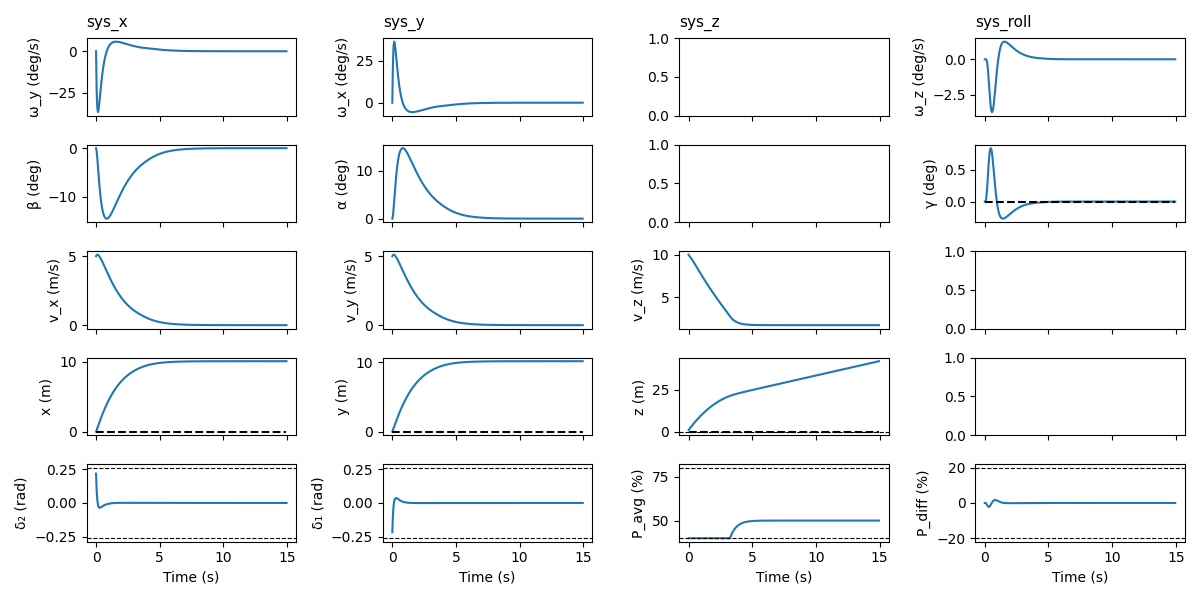

In [5]:
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, x_target)
plt.savefig('constant-disturbance-part4')

### Disturbance on new controller for part 5

In [6]:
from OffsetFreeLinearMPC.MPCVelControl import MPCVelControl
rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
mpc = MPCVelControl().new_controller(rocket, Ts, H)
rocket.mass = 1.5
rocket.fuel_rate = 0.0
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, ref = rocket.simulate_control(mpc, sim_time, H, x0, x_target=x_target, method='nonlinear')

Simulating time 0.00: 
Simulating time 0.05: 
Simulating time 0.10: 
Simulating time 0.15: 
Simulating time 0.20: 
Simulating time 0.25: 
Simulating time 0.30: 
Simulating time 0.35: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
Simulating time 0.40: 
 State beta violation: -0.19 < -0.17, 
 State alpha violation: 0.20 > 0.17, 
Simulating time 0.45: 
 State beta violation: -0.21 < -0.17, 
 State alpha violation: 0.21 > 0.17, 
Simulating time 0.50: 
 State beta violation: -0.22 < -0.17, 
 State alpha violation: 0.23 > 0.17, 
Simulating time 0.55: 
 State beta violation: -0.23 < -0.17, 
 State alpha violation: 0.24 > 0.17, 
Simulating time 0.60: 
 State beta violation: -0.24 < -0.17, 
 State alpha violation: 0.24 > 0.17, 
Simulating time 0.65: 
 State beta violation: -0.25 < -0.17, 
 State alpha violation: 0.25 > 0.17, 
Simulating time 0.70: 
 State beta violation: -0.25 < -0.17, 
 State alpha violation: 0.25 > 0.17, 
Simulating time 0.75: 
 State beta viol

In [7]:
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl, Ref=ref[:,:-1], T_ol=t_ol[...,:-1], X_ol=x_ol, U_ol=u_ol); 

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=299, step=2), IntSlider(value=0…

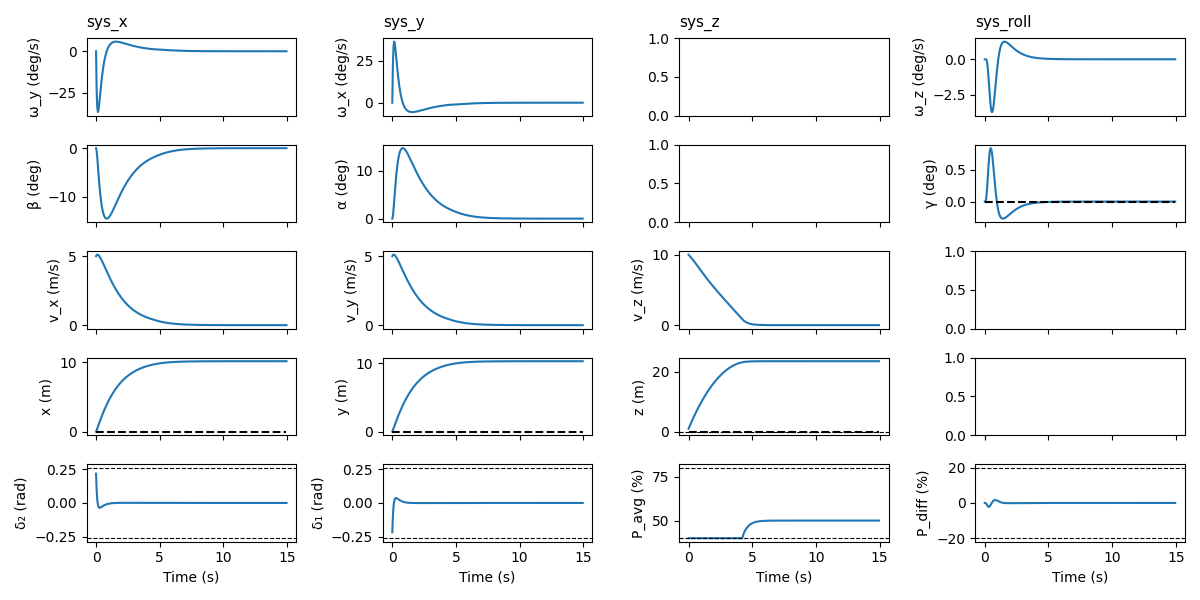

In [8]:
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, x_target)
plt.savefig('constant-disturbance-part5')